# Nəticəni təkzib etməyə çalışmaq

## Problem və data
Khan yüksək təsnifat score-u və yeast GO-da sıfır discovery nə qədər informativdir?
Bu notebook **saxlanmış control nəticələrini yenidən hesablayır**; 99 nested-CV
permutation fit-ini təkrarlamır. Tam icra: `python scripts/run_controls.py --experiment all`.
Protokol: `experiments/controls/protocol.json`. 63 Khan training nümunəsi və
84-gen yeast universe; əvvəlki 20 Khan test nümunəsi yeni control-a daxil edilməyib.

## Metod
GO singleton üçün hypergeometric p=K/N (gen term-dədirsə), əks halda p=1.
Bu xüsusi halda cədvəli birbaşa formuldan yoxlamaq mümkündür. ML üçün fold
proqnozları score-u, null cədvəli isə permutation p-ni təsdiqləyir.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from biolab.statistics import benjamini_hochberg
from biolab.provenance import verify_outputs
from IPython.display import display, Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists())
OUT=ROOT/'results/research-audit'
for name in ['expression-control','enrichment-control']:
    record=json.loads((OUT/name/'run.json').read_text())
    assert record['status']=='complete'
    verify_outputs(OUT/name,record)
print('Control output hashes verified')

Control output hashes verified


{'possible_singletons': 84, 'eligible_terms': 62, 'minimum_attainable_padj': np.float64(0.27678571428571425)}


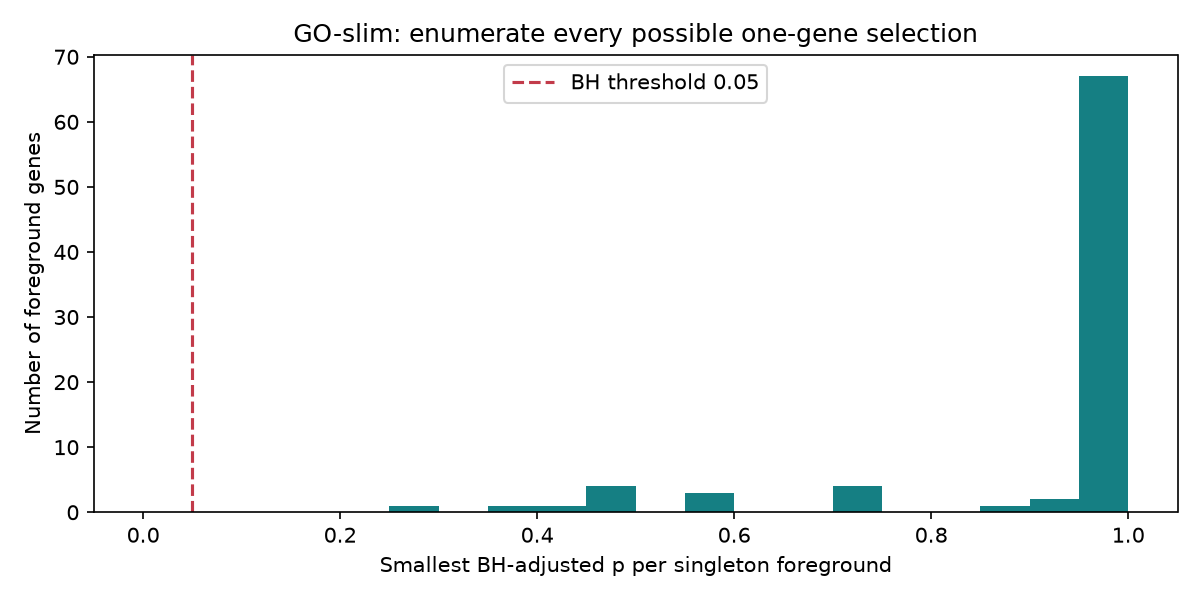

In [2]:
de=pd.read_csv(ROOT/'results/raw-examples/rna-model/differential_expression.csv').set_index('gene_id')
ann=pd.read_csv(ROOT/'datasets/examples/enrichment/sgd_go_slim_chrI.tsv',sep='\t')
universe=set(de.index[np.isfinite(de.padj)])
sets=[set(genes)&universe for _,genes in ann.groupby('go_id').gene_id]
sets=[members for members in sets if 2<=len(members)<len(universe)]
saved=pd.read_csv(OUT/'enrichment-control/singletons.csv')
direct=[]
for gene in saved.gene_id:
    p=[len(members)/len(universe) if gene in members else 1. for members in sets]
    direct.append(min(benjamini_hochberg(p)))
np.testing.assert_allclose(direct,saved.min_padj,atol=1e-14)
assert len(saved)==84 and saved.discoveries.sum()==0
print({'possible_singletons':len(saved),'eligible_terms':len(sets),'minimum_attainable_padj':min(direct)})
display(Image(filename=str(OUT/'enrichment-control/attainability.png')))

,fold,balanced_accuracy
0,1,1.00
1,2,0.95
2,3,1.00
3,4,1.00
4,5,1.00


{'nested_mean': np.float64(0.99), 'null_mean': np.float64(0.24193602693602692), 'permutation_p': 0.01, 'probe_jaccard': 0.25690877529311373}


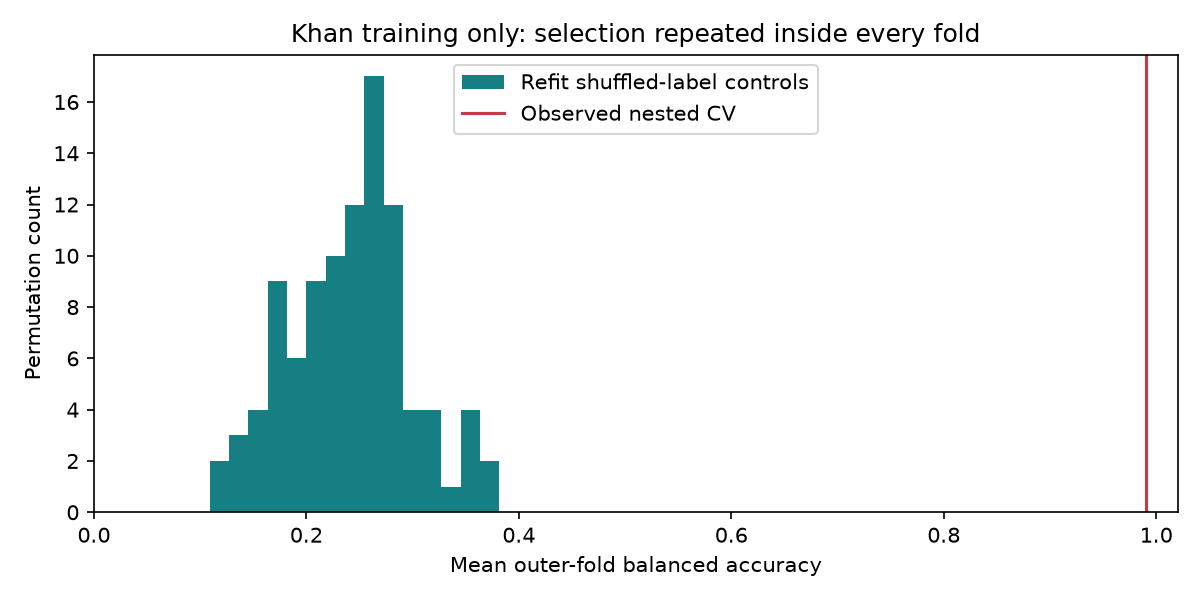

In [3]:
pred=pd.read_csv(OUT/'expression-control/out_of_fold_predictions.csv')
assert pred.sample_index0.is_unique and len(pred)==63
scores=pred.groupby('fold').apply(lambda g: balanced_accuracy_score(g.truth,g.prediction))
null=pd.read_csv(OUT/'expression-control/permutations.csv').balanced_accuracy
summary=json.loads((OUT/'expression-control/summary.json').read_text())
p=(1+sum(null>=scores.mean()))/(1+len(null))
np.testing.assert_allclose(scores.mean(),summary['mean_outer_balanced_accuracy'])
assert p==summary['permutation_pvalue']==.01
folds=json.loads((OUT/'expression-control/folds.json').read_text())
for fold in folds:
    assert not set(fold['train_indices0'])&set(fold['validation_indices0'])
display(pd.DataFrame({'fold':scores.index,'balanced_accuracy':scores.values}))
print({'nested_mean':scores.mean(),'null_mean':null.mean(),'permutation_p':p,'probe_jaccard':summary['mean_pairwise_selected_probe_jaccard']})
display(Image(filename=str(OUT/'expression-control/permutation_control.png')))

## Şərh və nəticə

- Sabit GO dizaynında tək-gen discovery mümkün olmadı. Sıfır nəticə pathway
  fəaliyyətinin yoxluğu demək deyil; bu biological effect-size power hesabı deyil.
- Nested CV=0.99 və null mean≈0.242; minimum resolution p=0.01. Outer fold-lar
  müstəqil cohort deyil, null range performance confidence interval deyil.
- Probe Jaccard≈0.257; yüksək prediction ilə sabit marker siyahısı ayrı nəticələrdir.
- Upstream preprocessing/donor metadata qeyri-müəyyəndir. Klinik və səbəb-nəticə iddiası çıxmır.

## Növbəti sınaq və məşq
Alfa və model grid-ini bu nəticəyə görə dəyişmədən, fixed-k feature stability
və ya təsdiqlənmiş xarici cohort protokolu yazın. 99 permutation-da p=0 yazmağın
niyə yanlış olduğunu və daha çox permutation-un hansı qeyri-müəyyənliyi
azaltdığını izah edin.